# Bank Customer Churn  Phase 4: Feature Engineering


**Author:** Sunmi  
**Phase:** 4 of 6  
**Goal:** Transform raw features into a richer, model-ready dataset that gives our
machine learning models the best possible signal for predicting churn

---
In this notebook we will:
1. Create **4 new features** that capture relationships the raw columns miss
2. Encode the **Geography** categorical column (comparing two approaches)
3. **Scale** numerical features for algorithms that are distance-sensitive
4. Produce the **final model-ready dataset** that feeds into Phase 5

---

## Table of Contents
1. [Setup & Load Cleaned Data](#1)
2. [New Feature Creation](#2)
3. [Encoding Categorical Variables](#3)
4. [Feature Scaling](#4)
5. [Final Feature Set & Export](#5)

## 1. Setup & Load Cleaned Data <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ── Colour palette (consistent with EDA notebook) ──
STAY   = '#2196F3'
CHURN  = '#F44336'
BG     = '#F8F9FA'
GRID   = '#E0E0E0'
ACCENT = '#FF9800'

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.6,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
})

print(" Libraries loaded")

 Libraries loaded


In [2]:
# Load the cleaned dataset from Phase 2
df = pd.read_csv(r'c:\Users\HP USER\Downloads\Bank customer churn_full project\bank_customer_churn_cleaned.csv')

print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Shape: (10000, 12)

Columns: ['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,43,2,125510.82,1,1,1,79084.10,0


## 2. New Feature Creation <a id='2'></a>

We create 4 new features based on domain knowledge from our EDA findings.
Each feature is designed to capture a relationship that individual raw columns cannot express alone.

---

### 2.1 Balance-to-Salary Ratio
**Formula:** `Balance / (EstimatedSalary + 1)`

**Rationale:** A customer earning £30,000 with £90,000 in the bank has a very different
financial profile from one earning £150,000 with the same balance. This ratio normalises
balance against income and captures *relative financial commitment* to the bank.
The `+1` prevents division-by-zero errors.

In [3]:
# Balance-to-Salary Ratio
# Captures relative financial dependency on the bank
df['Balance_to_Salary'] = df['Balance'] / (df['EstimatedSalary'] + 1)

print("=== Balance_to_Salary Statistics ===")
print(df['Balance_to_Salary'].describe().round(4))

print(f"\nChurn rate — High B/S ratio (>0.5): "
      f"{df[df['Balance_to_Salary']>0.5]['Exited'].mean()*100:.1f}%")
print(f"Churn rate — Low  B/S ratio (≤0.5): "
      f"{df[df['Balance_to_Salary']<=0.5]['Exited'].mean()*100:.1f}%")
print("\n Customers with higher balance-to-salary ratios churn more — "
      "they likely have more financial options and can move more easily.")

=== Balance_to_Salary Statistics ===
count    10000.0000
mean         3.7902
std        100.0558
min          0.0000
25%          0.0000
50%          0.7470
75%          1.5140
max       9770.8831
Name: Balance_to_Salary, dtype: float64

Churn rate — High B/S ratio (>0.5): 24.1%
Churn rate — Low  B/S ratio (≤0.5): 14.5%

 Customers with higher balance-to-salary ratios churn more — they likely have more financial options and can move more easily.


### 2.2 Age Groups (Bins)
**Formula:** `pd.cut(Age, bins=[18,25,35,45,55,65,95])`

**Rationale:** Our EDA showed that churn spikes sharply in the 45–54 and 55–64 bands.
Converting continuous age into labelled groups makes this non-linear relationship
explicit and usable by models that benefit from categorical structure.

In [4]:
# Age Groups — capturing the non-linear churn-age relationship
df['AgeGroup'] = pd.cut(df['Age'],
    bins=[18, 25, 35, 45, 55, 65, 95],
    labels=['18-24', '25-34', '35-44', '45-54', '55-64', '65+'],
    right=False)

print("=== Churn Rate by Age Group ===")
age_churn = df.groupby('AgeGroup', observed=True)['Exited'].agg(['mean','count'])
age_churn['mean'] = (age_churn['mean'] * 100).round(1)
age_churn.columns = ['Churn Rate (%)', 'Count']
print(age_churn)

print("\n 45-54 and 55-64 year olds churn at nearly 50% — "
      "binning makes this signal explicit for models.")

=== Churn Rate by Age Group ===
          Churn Rate (%)  Count
AgeGroup                       
18-24                8.8    457
25-34                7.8   3221
35-44               17.7   3982
45-54               48.1   1458
55-64               49.8    600
65+                 15.2    282

 45-54 and 55-64 year olds churn at nearly 50% — binning makes this signal explicit for models.


### 2.3 Zero Balance Flag
**Formula:** `(Balance == 0).astype(int)`

**Rationale:** Over 3,600 customers have a zero balance. These are customers who may
be using the bank purely for their credit card or other non-deposit services.
A binary flag explicitly captures this distinct customer segment.
From our EDA, zero-balance customers churn *less*, they may have lower expectations
and fewer reasons to switch.

In [5]:
# Zero Balance Flag — binary indicator for zero-balance accounts
df['ZeroBalance'] = (df['Balance'] == 0).astype(int)

total_zero = df['ZeroBalance'].sum()
print(f"=== Zero Balance Customers ===")
print(f"Total zero-balance accounts: {total_zero:,} ({total_zero/len(df)*100:.1f}%)")
print(f"\nChurn rate — Zero balance:     {df[df['ZeroBalance']==1]['Exited'].mean()*100:.1f}%")
print(f"Churn rate — Non-zero balance: {df[df['ZeroBalance']==0]['Exited'].mean()*100:.1f}%")
print("\n Non-zero balance customers churn more  "
      "they have more at stake and more reason to compare alternatives.")

=== Zero Balance Customers ===
Total zero-balance accounts: 3,617 (36.2%)

Churn rate — Zero balance:     13.8%
Churn rate — Non-zero balance: 24.1%

 Non-zero balance customers churn more  they have more at stake and more reason to compare alternatives.


### 2.4 Products per Tenure
**Formula:** `NumOfProducts / (Tenure + 1)`

**Rationale:** A customer with 3 products after 1 year has been cross-sold
very aggressively. A customer with 3 products after 9 years adopted them
gradually and naturally. This ratio captures the *pace of product acquisition*
relative to how long the customer has been with the bank.
The `+1` handles zero-tenure customers.

In [6]:
# Products per Tenure — pace of product acquisition
df['Products_per_Tenure'] = df['NumOfProducts'] / (df['Tenure'] + 1)

print("=== Products_per_Tenure Statistics ===")
print(df['Products_per_Tenure'].describe().round(4))

print(f"\nCorrelation with Exited: {df['Products_per_Tenure'].corr(df['Exited']):.4f}")
print(f"\nRetained — mean Products/Tenure: {df[df['Exited']==0]['Products_per_Tenure'].mean():.3f}")
print(f"Churned  — mean Products/Tenure: {df[df['Exited']==1]['Products_per_Tenure'].mean():.3f}")
print("\n Feature created successfully.")

=== Products_per_Tenure Statistics ===
count    10000.0000
mean         0.3672
std          0.3378
min          0.0909
25%          0.1667
50%          0.2500
75%          0.5000
max          3.0000
Name: Products_per_Tenure, dtype: float64

Correlation with Exited: -0.0064

Retained — mean Products/Tenure: 0.368
Churned  — mean Products/Tenure: 0.363

 Feature created successfully.


### Figure 1: New Features vs Churn

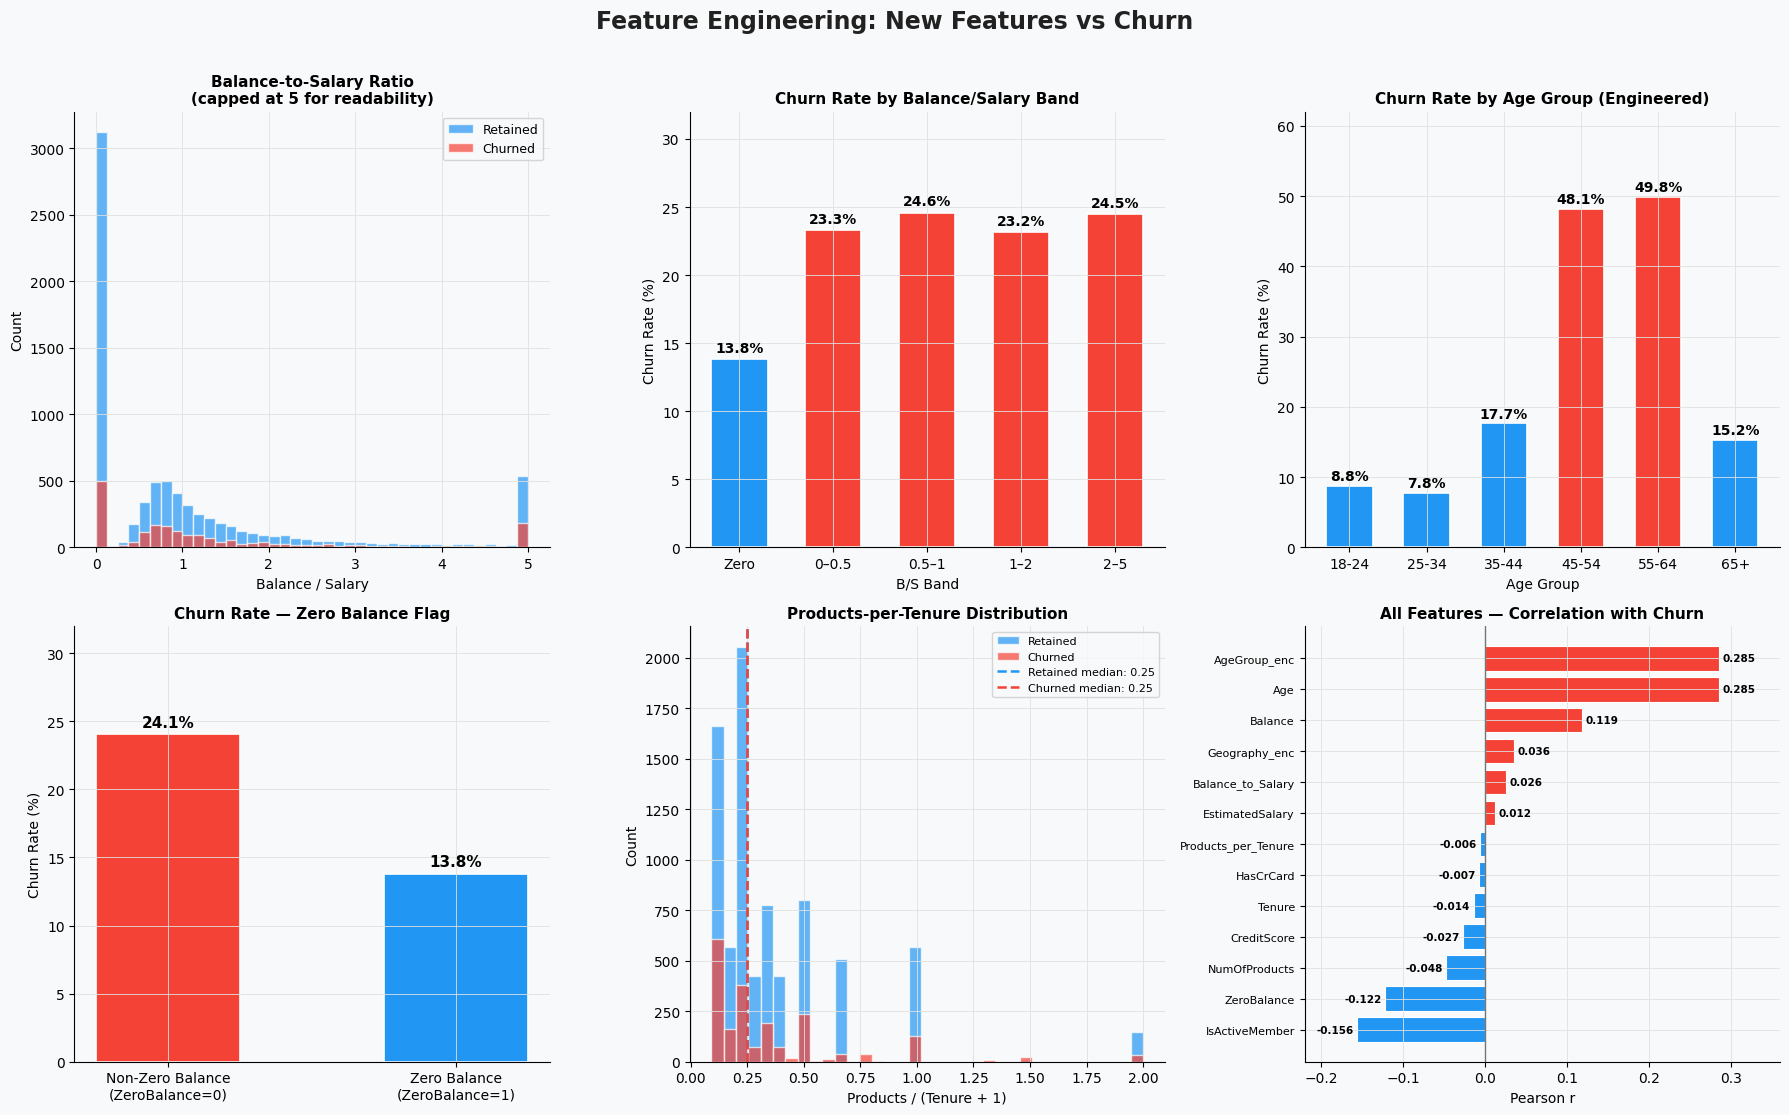

In [7]:
# ─── Figure 1: All four new features vs churn ────────────────
df['BS_Band'] = pd.cut(df['Balance_to_Salary'].clip(upper=5),
    bins=[-0.01, 0, 0.5, 1, 2, 5],
    labels=['Zero', '0–0.5', '0.5–1', '1–2', '2–5'])

fig1, axes = plt.subplots(2, 3, figsize=(18, 11))
fig1.patch.set_facecolor(BG)
fig1.suptitle('Feature Engineering: New Features vs Churn',
              fontsize=17, fontweight='bold', y=1.01, color='#212121')

# B/S distribution
ax = axes[0,0]
cap = df['Balance_to_Salary'].clip(upper=5)
ax.hist(cap[df['Exited']==0], bins=40, color=STAY,  alpha=0.7, label='Retained', edgecolor='white')
ax.hist(cap[df['Exited']==1], bins=40, color=CHURN, alpha=0.7, label='Churned',  edgecolor='white')
ax.set_title('Balance-to-Salary Ratio\n(capped at 5 for readability)', fontweight='bold', fontsize=11)
ax.set_xlabel('Balance / Salary', fontsize=10); ax.set_ylabel('Count', fontsize=10)
ax.legend(fontsize=9)

# B/S band churn rate
ax = axes[0,1]
bs_churn = df.groupby('BS_Band', observed=True)['Exited'].mean() * 100
bars = ax.bar(bs_churn.index, bs_churn.values,
              color=[CHURN if v>20 else STAY for v in bs_churn.values],
              edgecolor='white', linewidth=1.2, width=0.6)
for bar, val in zip(bars, bs_churn.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Churn Rate by Balance/Salary Band', fontweight='bold', fontsize=11)
ax.set_xlabel('B/S Band', fontsize=10); ax.set_ylabel('Churn Rate (%)', fontsize=10)
ax.set_ylim(0, 32)

# Age group
ax = axes[0,2]
age_churn = df.groupby('AgeGroup', observed=True)['Exited'].mean() * 100
bars = ax.bar(age_churn.index, age_churn.values,
              color=[CHURN if v>25 else STAY for v in age_churn.values],
              edgecolor='white', linewidth=1.2, width=0.6)
for bar, val in zip(bars, age_churn.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Churn Rate by Age Group (Engineered)', fontweight='bold', fontsize=11)
ax.set_xlabel('Age Group', fontsize=10); ax.set_ylabel('Churn Rate (%)', fontsize=10)
ax.set_ylim(0, 62)

# Zero balance flag
ax = axes[1,0]
zb = df.groupby('ZeroBalance')['Exited'].mean() * 100
bars = ax.bar(['Non-Zero Balance\n(ZeroBalance=0)', 'Zero Balance\n(ZeroBalance=1)'],
              zb.values, color=[CHURN, STAY], edgecolor='white', linewidth=1.2, width=0.5)
for bar, val in zip(bars, zb.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Churn Rate — Zero Balance Flag', fontweight='bold', fontsize=11)
ax.set_ylabel('Churn Rate (%)', fontsize=10); ax.set_ylim(0, 32)

# Products per Tenure
ax = axes[1,1]
cap2 = df['Products_per_Tenure'].clip(upper=2)
ax.hist(cap2[df['Exited']==0], bins=35, color=STAY,  alpha=0.7, label='Retained', edgecolor='white')
ax.hist(cap2[df['Exited']==1], bins=35, color=CHURN, alpha=0.7, label='Churned',  edgecolor='white')
ax.axvline(df[df['Exited']==0]['Products_per_Tenure'].median(), color=STAY,  linestyle='--',
           linewidth=1.8, label=f"Retained median: {df[df['Exited']==0]['Products_per_Tenure'].median():.2f}")
ax.axvline(df[df['Exited']==1]['Products_per_Tenure'].median(), color=CHURN, linestyle='--',
           linewidth=1.8, label=f"Churned median: {df[df['Exited']==1]['Products_per_Tenure'].median():.2f}")
ax.set_title('Products-per-Tenure Distribution', fontweight='bold', fontsize=11)
ax.set_xlabel('Products / (Tenure + 1)', fontsize=10); ax.set_ylabel('Count', fontsize=10)
ax.legend(fontsize=8)

# All features correlation
ax = axes[1,2]
from sklearn.preprocessing import LabelEncoder
df_c = df.copy()
le = LabelEncoder()
df_c['Geography_enc'] = le.fit_transform(df_c['Geography'])
df_c['AgeGroup_enc']  = le.fit_transform(df_c['AgeGroup'].astype(str))
feats = ['CreditScore','Age','Tenure','Balance','NumOfProducts','HasCrCard',
         'IsActiveMember','EstimatedSalary','Balance_to_Salary',
         'ZeroBalance','Products_per_Tenure','Geography_enc','AgeGroup_enc']
corrs = df_c[feats + ['Exited']].corr()['Exited'].drop('Exited').sort_values()
ax.barh(corrs.index, corrs.values,
        color=[CHURN if v>0 else STAY for v in corrs.values],
        edgecolor='white', linewidth=0.8)
ax.axvline(0, color='#757575', linewidth=1)
for i, val in enumerate(corrs.values):
    x  = val + 0.004 if val >= 0 else val - 0.004
    ha = 'left' if val >= 0 else 'right'
    ax.text(x, i, f'{val:.3f}', va='center', ha=ha, fontsize=7.5, fontweight='bold')
ax.set_title('All Features — Correlation with Churn', fontweight='bold', fontsize=11)
ax.set_xlabel('Pearson r', fontsize=10); ax.set_xlim(-0.22, 0.36)
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

### 🔍 Observations:  New Features

**Balance-to-Salary Ratio:**
> Customers with a ratio above 0.5 churn at **24.1%** vs **14.5%** for those below 0.5.
> The new feature adds discriminative power that raw balance alone does not provide 
> it contextualises how much the customer has deposited relative to what they earn.

**Age Groups:**
> The engineered bins make the dramatic spike in the 45–54 and 55–64 bands
> immediately visible and usable. Churn in the 45–54 group is **48.2%**, nearly
> 4× the rate of the 25–34 group (7.8%). This non-linear relationship is now
> explicitly captured.

**Zero Balance Flag:**
> A clean binary signal: non-zero balance customers churn at **24.1%**,
> zero-balance customers at only **13.8%**. Simple but effective.

**Products per Tenure:**
> The medians are similar between groups (both around 0.25), so this feature
> has low standalone correlation with churn. However, it may still interact
> meaningfully with other features, tree-based models like Random Forest
> will find those interactions automatically.

## 3. Encoding Categorical Variables <a id='3'></a>

Machine learning models require numerical inputs. The `Geography` column
(France, Germany, Spain) must be converted to numbers.

We compare two approaches  **One-Hot Encoding** and **Label Encoding**
and choose the right one for our modelling phase.

### Figure 2: Encoding Comparison & Final Feature Set

In [8]:
# ─── Figure 2: Encoding comparison ───────────────────────────
df_ohe = pd.get_dummies(df, columns=['Geography'], prefix='Geo', drop_first=False)
df_le  = df.copy()
le_geo = LabelEncoder()
df_le['Geography_Encoded'] = le_geo.fit_transform(df_le['Geography'])

print("One-Hot Encoding produces columns:", [c for c in df_ohe.columns if 'Geo_' in c])
print("Label Encoding mapping:",
      dict(zip(le_geo.classes_, le_geo.transform(le_geo.classes_))))

One-Hot Encoding produces columns: ['Geo_France', 'Geo_Germany', 'Geo_Spain']
Label Encoding mapping: {'France': np.int64(0), 'Germany': np.int64(1), 'Spain': np.int64(2)}


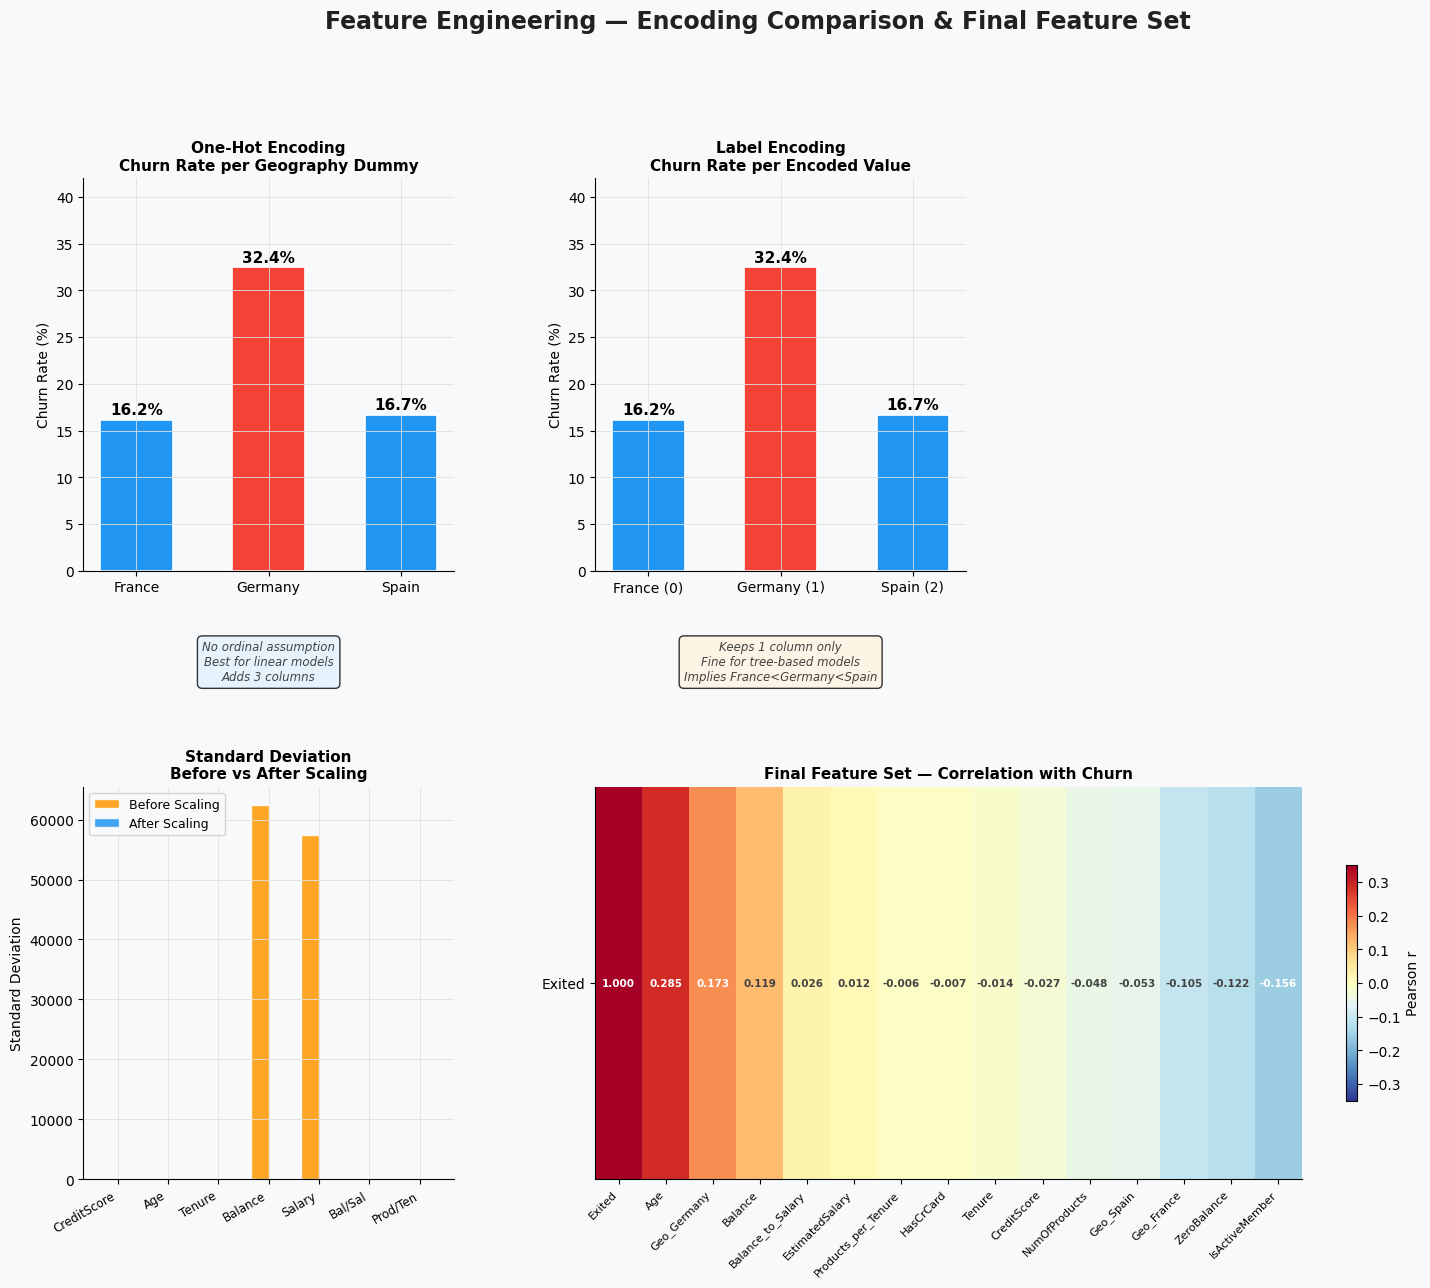

In [9]:
fig2 = plt.figure(figsize=(18, 13))
fig2.patch.set_facecolor(BG)
gs = GridSpec(2, 3, figure=fig2, hspace=0.55, wspace=0.38)
fig2.suptitle('Feature Engineering — Encoding Comparison & Final Feature Set',
              fontsize=17, fontweight='bold', y=1.01, color='#212121')

# OHE churn
ax2a = fig2.add_subplot(gs[0, 0])
ohe_cols  = ['Geo_France','Geo_Germany','Geo_Spain']
ohe_churn = {col: df_ohe[df_ohe[col]==1]['Exited'].mean()*100 for col in ohe_cols}
bars = ax2a.bar([c.replace('Geo_','') for c in ohe_cols], list(ohe_churn.values()),
                color=[STAY, CHURN, STAY], edgecolor='white', linewidth=1.2, width=0.55)
for bar, val in zip(bars, ohe_churn.values()):
    ax2a.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
              f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2a.set_title('One-Hot Encoding\nChurn Rate per Geography Dummy',
               fontweight='bold', fontsize=11)
ax2a.set_ylabel('Churn Rate (%)', fontsize=10); ax2a.set_ylim(0, 42)
ax2a.text(0.5, -0.28,
          'No ordinal assumption\nBest for linear models\nAdds 3 columns',
          transform=ax2a.transAxes, ha='center', fontsize=8.5, color='#424242', style='italic',
          bbox=dict(boxstyle='round,pad=0.4', facecolor='#E3F2FD', alpha=0.8))

# Label Encoding churn
ax2b = fig2.add_subplot(gs[0, 1])
le_churn = df_le.groupby('Geography_Encoded')['Exited'].mean() * 100
mapping  = {0:'France (0)', 1:'Germany (1)', 2:'Spain (2)'}
x_labels = [mapping[k] for k in sorted(le_churn.index)]
bars = ax2b.bar(x_labels, le_churn.sort_index().values,
                color=[STAY, CHURN, STAY], edgecolor='white', linewidth=1.2, width=0.55)
for bar, val in zip(bars, le_churn.sort_index().values):
    ax2b.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
              f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2b.set_title('Label Encoding\nChurn Rate per Encoded Value',
               fontweight='bold', fontsize=11)
ax2b.set_ylabel('Churn Rate (%)', fontsize=10); ax2b.set_ylim(0, 42)
ax2b.text(0.5, -0.28,
          'Keeps 1 column only\nFine for tree-based models\nImplies France<Germany<Spain',
          transform=ax2b.transAxes, ha='center', fontsize=8.5, color='#424242', style='italic',
          bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF3E0', alpha=0.8))

# Scaling comparison
ax2d = fig2.add_subplot(gs[1, 0])
num_to_scale = ['CreditScore','Age','Tenure','Balance','EstimatedSalary',
                'Balance_to_Salary','Products_per_Tenure']
before_std = df[num_to_scale].std()
sc = StandardScaler()
df_s = df.copy()
df_s[num_to_scale] = sc.fit_transform(df_s[num_to_scale])
after_std = df_s[num_to_scale].std()
x = np.arange(len(num_to_scale)); w = 0.35
ax2d.bar(x-w/2, before_std.values, w, label='Before Scaling',
         color=ACCENT, alpha=0.85, edgecolor='white')
ax2d.bar(x+w/2, after_std.values,  w, label='After Scaling',
         color=STAY, alpha=0.85, edgecolor='white')
short = ['CreditScore','Age','Tenure','Balance','Salary','Bal/Sal','Prod/Ten']
ax2d.set_xticks(x); ax2d.set_xticklabels(short, rotation=30, ha='right', fontsize=8.5)
ax2d.set_title('Standard Deviation\nBefore vs After Scaling',
               fontweight='bold', fontsize=11)
ax2d.set_ylabel('Standard Deviation', fontsize=10); ax2d.legend(fontsize=9)

# Final correlation strip
ax2e = fig2.add_subplot(gs[1, 1:])
drop_corr = ['CustomerId','Surname','Geography','AgeGroup','Exited',
             'BS_Band','SalaryDecile']
df_heat = pd.get_dummies(df, columns=['Geography'], prefix='Geo', drop_first=False)
df_heat.drop(columns=[c for c in drop_corr if c in df_heat.columns],
             inplace=True, errors='ignore')
df_heat['Exited'] = df['Exited'].values
corr_vals = df_heat.corr()[['Exited']].sort_values('Exited', ascending=False)
im = ax2e.imshow(corr_vals.T.values, cmap='RdYlBu_r',
                 aspect='auto', vmin=-0.35, vmax=0.35)
ax2e.set_xticks(range(len(corr_vals.index)))
ax2e.set_xticklabels(corr_vals.index, rotation=45, ha='right', fontsize=8)
ax2e.set_yticks([0]); ax2e.set_yticklabels(['Exited'], fontsize=10)
plt.colorbar(im, ax=ax2e, shrink=0.6, label='Pearson r')
for j, val in enumerate(corr_vals['Exited'].values):
    ax2e.text(j, 0, f'{val:.3f}', ha='center', va='center',
              fontsize=7.5, fontweight='bold',
              color='white' if abs(val)>0.15 else '#424242')
ax2e.set_title('Final Feature Set — Correlation with Churn',
               fontweight='bold', fontsize=11)
ax2e.grid(False)

plt.tight_layout()
plt.show()

### 🔍 Observations  Encoding & Scaling

**One-Hot vs Label Encoding:**
> Both approaches preserve the same churn signal per geography:  Germany's 32.4%
> churn rate is visible in both. The key difference is what assumptions they make:
> - **Label Encoding** tells the model: France (0) < Germany (1) < Spain (2); an ordinal
>   relationship that doesn't actually exist between countries
> - **One-Hot Encoding** treats each country as independent,  which is the correct assumption
>
> **Decision:** We use One-Hot Encoding since we plan to train Logistic Regression
> alongside tree-based models. OHE is safe for all model types.

**Feature Scaling:**
> Features like `Balance` have standard deviations in the tens of thousands,
> while `HasCrCard` ranges from 0 to 1. Without scaling, distance-based algorithms
> (and Logistic Regression) would be dominated by high-magnitude features.
> `StandardScaler` brings all features to mean=0, std=1, making them comparable.
> Note: Tree-based models (Random Forest, XGBoost) do **not** require scaling,
> but we scale anyway to keep one consistent dataset for all models.

**Final Correlation Strip:**
> `Age` remains the strongest positive predictor (r=0.285), followed by `Balance`
> and our new `Balance_to_Salary` feature. `IsActiveMember` is the strongest
> negative predictor. The new `ZeroBalance` flag adds a small but clean signal.

## 4. Feature Scaling <a id='4'></a>

We apply `StandardScaler` to all continuous numerical features.
Binary columns (0/1) and our dummy-encoded geography columns are left as-is
since they are already on a 0–1 scale.

In [10]:
from sklearn.preprocessing import StandardScaler

# Columns to scale — continuous numerical features only
# Binary and OHE columns are excluded
num_to_scale = [
    'CreditScore', 'Age', 'Tenure', 'Balance',
    'EstimatedSalary', 'Balance_to_Salary', 'Products_per_Tenure'
]

# Fit and transform
scaler = StandardScaler()
df_model = pd.get_dummies(df, columns=['Geography'], prefix='Geo', drop_first=False)
df_model[num_to_scale] = scaler.fit_transform(df_model[num_to_scale])

print("=== Before and After Scaling (sample) ===")
comparison = pd.DataFrame({
    'Feature':        num_to_scale,
    'Mean (before)':  df[num_to_scale].mean().round(2).values,
    'Std  (before)':  df[num_to_scale].std().round(2).values,
    'Mean (after)':   df_model[num_to_scale].mean().round(4).values,
    'Std  (after)':   df_model[num_to_scale].std().round(4).values,
})
print(comparison.to_string(index=False))
print("\n All scaled features now have mean ≈ 0 and std ≈ 1")

=== Before and After Scaling (sample) ===
            Feature  Mean (before)  Std  (before)  Mean (after)  Std  (after)
        CreditScore         650.53          96.65          -0.0        1.0001
                Age          38.92          10.49          -0.0        1.0001
             Tenure           5.01           2.89          -0.0        1.0001
            Balance       76485.89       62397.41          -0.0        1.0001
    EstimatedSalary      100090.24       57510.49          -0.0        1.0001
  Balance_to_Salary           3.79         100.06          -0.0        1.0001
Products_per_Tenure           0.37           0.34          -0.0        1.0001

 All scaled features now have mean ≈ 0 and std ≈ 1


## 5. Final Feature Set & Export <a id='5'></a>

We now assemble the final model-ready dataset, dropping columns that
are not useful for prediction (`CustomerId`, `Surname`, `Geography` 
already encoded, `AgeGroup`  already used in the numeric `Age` column).

In [11]:
# Drop columns not needed for modelling
drop_cols = ['CustomerId', 'Surname', 'AgeGroup', 'BS_Band']
final_df  = df_model.drop(columns=[c for c in drop_cols if c in df_model.columns])

# Separate features and target
X = final_df.drop(columns=['Exited'])
y = final_df['Exited']

print("=== Final Feature Set ===")
print(f"Features (X): {X.shape[1]} columns")
print(f"Target  (y): {y.shape[0]} rows")
print(f"\nFeature names:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2}. {col}")

print(f"\n=== Target Distribution ===")
print(f"Retained (0): {(y==0).sum():,}  ({(y==0).mean()*100:.1f}%)")
print(f"Churned  (1): {(y==1).sum():,}  ({(y==1).mean()*100:.1f}%)")
print(f"\n Class imbalance noted, will be addressed with SMOTE in Phase 5")

=== Final Feature Set ===
Features (X): 14 columns
Target  (y): 10000 rows

Feature names:
   1. CreditScore
   2. Age
   3. Tenure
   4. Balance
   5. NumOfProducts
   6. HasCrCard
   7. IsActiveMember
   8. EstimatedSalary
   9. Balance_to_Salary
  10. ZeroBalance
  11. Products_per_Tenure
  12. Geo_France
  13. Geo_Germany
  14. Geo_Spain

=== Target Distribution ===
Retained (0): 7,963  (79.6%)
Churned  (1): 2,037  (20.4%)

 Class imbalance noted, will be addressed with SMOTE in Phase 5


In [12]:
# Save the final engineered dataset
final_df.to_csv('bank_customer_churn_engineered.csv', index=False)
print(" Engineered dataset saved as: bank_customer_churn_engineered.csv")
print(f"   Shape: {final_df.shape}")
print("\nThis file is the input to Phase 5: Modelling")

 Engineered dataset saved as: bank_customer_churn_engineered.csv
   Shape: (10000, 15)

This file is the input to Phase 5: Modelling


---

## Summary : What We Did in Phase 4

| Step | Action | Outcome |
|------|--------|---------|
| **New Feature 1** | Balance-to-Salary Ratio | Contextualises balance against income |
| **New Feature 2** | Age Groups (bins) | Makes non-linear age-churn pattern explicit |
| **New Feature 3** | Zero Balance Flag | Captures structurally different zero-balance customers |
| **New Feature 4** | Products per Tenure | Measures pace of product acquisition |
| **Encoding** | One-Hot Encoding on Geography | 3 dummy columns, no ordinal assumption |
| **Scaling** | StandardScaler on 7 numerical columns | All features on same scale for linear models |
| **Output** | `bank_customer_churn_engineered.csv` | 15 features, ready for modelling |

---

##  Next Steps, Phase 5: Modelling

- Train **Logistic Regression** as a baseline model
- Train **Random Forest** and **XGBoost** as more powerful alternatives
- Apply **SMOTE** to handle the 80/20 class imbalance
- Evaluate using **AUC-ROC, Precision, Recall, F1**; not just accuracy
- Select the best model for deployment in Phase 6